In [2]:
import os
import glob
import csv
import random
import time

import numpy as np
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


# ============================================================
# 1. Configuration
# ============================================================

DATA_ROOT = r"Training dataset"

# ------------------------------------------------------------
# Change this to the LNO training result folder containing:
#
#     best_latent_neural_operator.pt
#
# Example:
#
# RUN_DIR = r"latent_neural_operator_results/run_20260824_085448"
# ------------------------------------------------------------

RUN_DIR = r"latent_neural_operator_results/run_20260826_151559"


MODEL_PATH = os.path.join(
    RUN_DIR,
    "best_latent_neural_operator.pt"
)

SUMMARY_PATH = os.path.join(
    RUN_DIR,
    "quantitative_metrics.txt"
)

CSV_PATH = os.path.join(
    RUN_DIR,
    "per_sample_metrics.csv"
)


# ============================================================
# 2. Dataset split
#
# MUST be identical to training
# ============================================================

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

SEED = 42


# ============================================================
# 3. LNO architecture
#
# MUST be identical to training
# ============================================================

IN_CHANNELS = 1
OUT_CHANNELS = 1

LATENT_WIDTH = 128

LATENT_MODES_T = 24
LATENT_MODES_X = 12

N_OPERATOR_LAYERS = 4


# ============================================================
# 4. Data dimensions
# ============================================================

NT = 501
NX = 200


# ============================================================
# 5. Evaluation batch size
# ============================================================

BATCH_SIZE = 8


# ============================================================
# 6. Device
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 72)
print("LATENT NEURAL OPERATOR QUANTITATIVE EVALUATION")
print("=" * 72)

print("\nUsing device:")
print(DEVICE)


# ============================================================
# 7. Check model
# ============================================================

if not os.path.exists(MODEL_PATH):

    raise FileNotFoundError(
        "\nCannot find trained LNO model:\n"
        f"{MODEL_PATH}\n\n"
        "Please modify RUN_DIR."
    )


print("\nTrained model:")
print(MODEL_PATH)


# ============================================================
# 8. Random seed
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 9. Find all MAT files
# ============================================================

all_files = glob.glob(

    os.path.join(
        DATA_ROOT,
        "**",
        "*.mat"
    ),

    recursive=True
)


all_files = sorted(all_files)


print(
    "\nTotal .mat samples found:",
    len(all_files)
)


if len(all_files) == 0:

    raise RuntimeError(
        f"No MAT files found under:\n"
        f"{DATA_ROOT}"
    )


# ============================================================
# 10. Reproduce train / val / test split
#
# IMPORTANT:
#
# Must reproduce training procedure exactly:
#
# sorted
# ->
# random.seed(42)
# ->
# random.shuffle
# ============================================================

random.shuffle(all_files)


n_total = len(all_files)

n_train = int(
    n_total * TRAIN_RATIO
)

n_val = int(
    n_total * VAL_RATIO
)


train_files = all_files[
    :n_train
]

val_files = all_files[
    n_train:
    n_train + n_val
]

test_files = all_files[
    n_train + n_val:
]


print("\nDataset split:")

print(
    "Train samples:",
    len(train_files)
)

print(
    "Val samples  :",
    len(val_files)
)

print(
    "Test samples :",
    len(test_files)
)


# ============================================================
# 11. Utility: shape correction
# ============================================================

def correct_shape(x, name, mat_path):

    if x.shape == (NX, NT):
        x = x.T

    if x.shape != (NT, NX):

        raise ValueError(
            f"Wrong {name} shape in:\n"
            f"{mat_path}\n"
            f"Shape = {x.shape}"
        )

    return x


# ============================================================
# 12. Compute normalization statistics
#
# IMPORTANT:
#
# Training data ONLY
# ============================================================

def compute_statistics(file_list):

    pt_sum = 0.0
    pt_sq_sum = 0.0

    pa_sum = 0.0
    pa_sq_sum = 0.0

    n_elements = 0


    print(
        "\nCalculating normalization statistics "
        "from training set..."
    )


    for mat_path in tqdm(

        file_list,

        desc="Statistics",

        ncols=100

    ):

        with h5py.File(
            mat_path,
            "r"
        ) as f:

            PT = np.asarray(
                f["PT"],
                dtype=np.float64
            )

            PA = np.asarray(
                f["PA"],
                dtype=np.float64
            )


        PT = correct_shape(
            PT,
            "PT",
            mat_path
        )

        PA = correct_shape(
            PA,
            "PA",
            mat_path
        )


        pt_sum += PT.sum()

        pt_sq_sum += np.square(
            PT
        ).sum()


        pa_sum += PA.sum()

        pa_sq_sum += np.square(
            PA
        ).sum()


        n_elements += PT.size


    pt_mean = (
        pt_sum
        /
        n_elements
    )

    pa_mean = (
        pa_sum
        /
        n_elements
    )


    pt_var = (
        pt_sq_sum
        /
        n_elements
        -
        pt_mean ** 2
    )

    pa_var = (
        pa_sq_sum
        /
        n_elements
        -
        pa_mean ** 2
    )


    pt_var = max(
        pt_var,
        0.0
    )

    pa_var = max(
        pa_var,
        0.0
    )


    pt_std = (
        np.sqrt(pt_var)
        +
        1e-8
    )

    pa_std = (
        np.sqrt(pa_var)
        +
        1e-8
    )


    return (
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    )


(
    pt_mean,
    pt_std,
    pa_mean,
    pa_std

) = compute_statistics(
    train_files
)


print("\nNormalization statistics:")

print(
    f"PT mean = {pt_mean:.8e}"
)

print(
    f"PT std  = {pt_std:.8e}"
)

print(
    f"PA mean = {pa_mean:.8e}"
)

print(
    f"PA std  = {pa_std:.8e}"
)


# ============================================================
# 13. Dataset
# ============================================================

class MatHeatAcousticDataset(Dataset):

    def __init__(
        self,
        file_list,
        pt_mean,
        pt_std,
        pa_mean,
        pa_std
    ):

        self.file_list = file_list

        self.pt_mean = pt_mean
        self.pt_std = pt_std

        self.pa_mean = pa_mean
        self.pa_std = pa_std


    def __len__(self):

        return len(
            self.file_list
        )


    def __getitem__(
        self,
        idx
    ):

        mat_path = self.file_list[
            idx
        ]


        with h5py.File(
            mat_path,
            "r"
        ) as f:

            PT = np.asarray(
                f["PT"],
                dtype=np.float32
            )

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )


        PT = correct_shape(
            PT,
            "PT",
            mat_path
        )

        PA = correct_shape(
            PA,
            "PA",
            mat_path
        )


        # --------------------------------------------------------
        # Normalize
        # --------------------------------------------------------

        PT = (
            PT
            -
            self.pt_mean
        ) / self.pt_std


        PA = (
            PA
            -
            self.pa_mean
        ) / self.pa_std


        # [T,X] -> [C,T,X]

        PT = torch.tensor(
            PT,
            dtype=torch.float32
        ).unsqueeze(0)


        PA = torch.tensor(
            PA,
            dtype=torch.float32
        ).unsqueeze(0)


        return (
            PT,
            PA,
            mat_path
        )


# ============================================================
# 14. Test loader
# ============================================================

test_dataset = MatHeatAcousticDataset(

    test_files,

    pt_mean,
    pt_std,

    pa_mean,
    pa_std
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print("\nTest loader ready.")


# ============================================================
# 15. Basic convolution block
# ============================================================

class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        groups = min(
            8,
            out_channels
        )


        while (
            out_channels % groups != 0
            and
            groups > 1
        ):
            groups -= 1


        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                groups,
                out_channels
            ),

            nn.GELU()
        )


        if in_channels != out_channels:

            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.shortcut = nn.Identity()


    def forward(
        self,
        x
    ):

        residual = self.shortcut(x)

        x = self.block(x)

        return (
            x
            +
            residual
        )


# ============================================================
# 16. PT Encoder
# ============================================================

class PTEncoder(nn.Module):

    def __init__(
        self,
        latent_width=128
    ):

        super().__init__()


        self.enc1 = ConvBlock(
            3,
            32
        )

        self.enc2 = ConvBlock(
            32,
            64
        )

        self.enc3 = ConvBlock(
            64,
            96
        )

        self.enc4 = ConvBlock(
            96,
            latent_width
        )


    def forward(
        self,
        x
    ):

        x = self.enc1(x)

        x = F.avg_pool2d(
            x,
            kernel_size=2,
            stride=2,
            ceil_mode=True
        )


        x = self.enc2(x)

        x = F.avg_pool2d(
            x,
            kernel_size=2,
            stride=2,
            ceil_mode=True
        )


        x = self.enc3(x)

        x = F.avg_pool2d(
            x,
            kernel_size=2,
            stride=2,
            ceil_mode=True
        )


        x = self.enc4(x)

        return x


# ============================================================
# 17. Latent spectral convolution
# ============================================================

class LatentSpectralConv2d(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        self.in_channels = in_channels
        self.out_channels = out_channels

        self.modes_t = modes_t
        self.modes_x = modes_x


        scale = (
            1.0
            /
            (
                in_channels
                *
                out_channels
            )
        )


        self.weights_pos = nn.Parameter(

            scale
            *
            torch.randn(
                in_channels,
                out_channels,
                modes_t,
                modes_x,
                dtype=torch.cfloat
            )
        )


        self.weights_neg = nn.Parameter(

            scale
            *
            torch.randn(
                in_channels,
                out_channels,
                modes_t,
                modes_x,
                dtype=torch.cfloat
            )
        )


    def compl_mul2d(
        self,
        x,
        weights
    ):

        return torch.einsum(
            "bixy,ioxy->boxy",
            x,
            weights
        )


    def forward(
        self,
        x
    ):

        B, C, T, X = x.shape


        x_ft = torch.fft.rfftn(
            x,
            dim=(-2, -1)
        )


        out_ft = torch.zeros(

            B,

            self.out_channels,

            T,

            X // 2 + 1,

            dtype=torch.cfloat,

            device=x.device
        )


        mt = min(
            self.modes_t,
            T // 2
        )


        mx = min(
            self.modes_x,
            X // 2 + 1
        )


        if mt > 0 and mx > 0:

            out_ft[
                :,
                :,
                :mt,
                :mx
            ] = self.compl_mul2d(

                x_ft[
                    :,
                    :,
                    :mt,
                    :mx
                ],

                self.weights_pos[
                    :,
                    :,
                    :mt,
                    :mx
                ]
            )


            out_ft[
                :,
                :,
                -mt:,
                :mx
            ] = self.compl_mul2d(

                x_ft[
                    :,
                    :,
                    -mt:,
                    :mx
                ],

                self.weights_neg[
                    :,
                    :,
                    :mt,
                    :mx
                ]
            )


        x = torch.fft.irfftn(

            out_ft,

            s=(
                T,
                X
            ),

            dim=(-2, -1)
        )


        return x


# ============================================================
# 18. Latent operator block
# ============================================================

class LatentOperatorBlock(nn.Module):

    def __init__(
        self,
        channels,
        modes_t,
        modes_x
    ):

        super().__init__()


        self.spectral = LatentSpectralConv2d(
            channels,
            channels,
            modes_t,
            modes_x
        )


        self.local = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )


        self.refine = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )


        groups = min(
            8,
            channels
        )


        while (
            channels % groups != 0
            and
            groups > 1
        ):

            groups -= 1


        self.norm = nn.GroupNorm(
            groups,
            channels
        )


    def forward(
        self,
        x
    ):

        residual = x


        x1 = self.spectral(x)

        x2 = self.local(x)


        x = (
            x1
            +
            x2
        )


        x = self.norm(x)

        x = F.gelu(x)


        x = (
            x
            +
            self.refine(x)
        )


        x = (
            x
            +
            residual
        )


        x = F.gelu(x)


        return x


# ============================================================
# 19. Latent neural operator
# ============================================================

class LatentOperator(nn.Module):

    def __init__(
        self,
        channels,
        modes_t,
        modes_x,
        n_layers
    ):

        super().__init__()


        self.layers = nn.ModuleList(

            [

                LatentOperatorBlock(

                    channels=channels,

                    modes_t=modes_t,

                    modes_x=modes_x
                )

                for _ in range(
                    n_layers
                )
            ]
        )


        self.cross_physics_projection = nn.Sequential(

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1
            ),

            nn.GELU(),

            nn.Conv2d(
                channels,
                channels,
                kernel_size=1
            )
        )


    def forward(
        self,
        x
    ):

        for layer in self.layers:

            x = layer(x)


        residual = x

        x = self.cross_physics_projection(x)

        x = (
            x
            +
            residual
        )


        return x


# ============================================================
# 20. PA Decoder
# ============================================================

class PADecoder(nn.Module):

    def __init__(
        self,
        latent_width=128,
        out_channels=1
    ):

        super().__init__()


        self.dec3 = ConvBlock(
            latent_width,
            96
        )

        self.dec2 = ConvBlock(
            96,
            64
        )

        self.dec1 = ConvBlock(
            64,
            32
        )


        self.final_refine = nn.Sequential(

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                32,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.GELU()
        )


        self.output = nn.Conv2d(
            16,
            out_channels,
            kernel_size=1
        )


    def forward(
        self,
        x,
        output_size
    ):

        target_t = output_size[0]
        target_x = output_size[1]


        size2 = (

            int(
                np.ceil(
                    target_t / 4
                )
            ),

            int(
                np.ceil(
                    target_x / 4
                )
            )
        )


        x = F.interpolate(
            x,
            size=size2,
            mode="bilinear",
            align_corners=False
        )

        x = self.dec3(x)


        size1 = (

            int(
                np.ceil(
                    target_t / 2
                )
            ),

            int(
                np.ceil(
                    target_x / 2
                )
            )
        )


        x = F.interpolate(
            x,
            size=size1,
            mode="bilinear",
            align_corners=False
        )

        x = self.dec2(x)


        x = F.interpolate(

            x,

            size=(
                target_t,
                target_x
            ),

            mode="bilinear",

            align_corners=False
        )


        x = self.dec1(x)


        x = self.final_refine(x)

        x = self.output(x)


        return x


# ============================================================
# 21. Complete LNO
# ============================================================

class LatentNeuralOperator2D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        latent_width=128,
        modes_t=24,
        modes_x=12,
        n_operator_layers=4
    ):

        super().__init__()


        self.encoder = PTEncoder(
            latent_width=latent_width
        )


        self.operator = LatentOperator(

            channels=latent_width,

            modes_t=modes_t,

            modes_x=modes_x,

            n_layers=n_operator_layers
        )


        self.decoder = PADecoder(

            latent_width=latent_width,

            out_channels=out_channels
        )


    def get_grid(
        self,
        shape,
        device
    ):

        B, C, T, X = shape


        t = torch.linspace(
            0.0,
            1.0,
            T,
            device=device
        )


        x = torch.linspace(
            0.0,
            1.0,
            X,
            device=device
        )


        tt, xx = torch.meshgrid(
            t,
            x,
            indexing="ij"
        )


        grid = torch.stack(
            [
                tt,
                xx
            ],
            dim=0
        )


        grid = (
            grid
            .unsqueeze(0)
            .repeat(
                B,
                1,
                1,
                1
            )
        )


        return grid


    def forward(
        self,
        pt
    ):

        original_size = pt.shape[
            -2:
        ]


        grid = self.get_grid(
            pt.shape,
            pt.device
        )


        # PT + t + x

        x = torch.cat(
            [
                pt,
                grid
            ],
            dim=1
        )


        # PT -> latent PT

        z_pt = self.encoder(x)


        # latent PT -> latent PA

        z_pa = self.operator(
            z_pt
        )


        # latent PA -> PA

        pa = self.decoder(

            z_pa,

            output_size=original_size
        )


        return pa


# ============================================================
# 22. Build model
# ============================================================

model = LatentNeuralOperator2D(

    in_channels=IN_CHANNELS,

    out_channels=OUT_CHANNELS,

    latent_width=LATENT_WIDTH,

    modes_t=LATENT_MODES_T,

    modes_x=LATENT_MODES_X,

    n_operator_layers=N_OPERATOR_LAYERS

).to(
    DEVICE
)


# ============================================================
# 23. Load trained model
# ============================================================

print(
    "\nLoading trained LNO..."
)


state_dict = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=True
)


model.load_state_dict(
    state_dict
)


model.eval()


print(
    "LNO loaded successfully."
)


# ============================================================
# Parameter count
# ============================================================

n_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)


print(
    f"\nTrainable parameters: "
    f"{n_parameters:,}"
)


# ============================================================
# 24. Evaluation storage
# ============================================================

global_sse = 0.0
global_sae = 0.0

global_target_sq = 0.0
global_target_sum = 0.0

global_n = 0


per_sample_results = []


# ============================================================
# 25. Quantitative evaluation
# ============================================================

print(
    "\nEvaluating test set..."
)


# ------------------------------------------------------------
# Synchronize GPU for accurate inference timing
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.synchronize()


start_time = time.perf_counter()


sample_counter = 0


with torch.no_grad():

    for (
        PT_norm,
        PA_norm,
        file_paths
    ) in tqdm(

        test_loader,

        desc="Testing",

        ncols=100

    ):


        PT_norm = PT_norm.to(
            DEVICE,
            non_blocking=True
        )


        # --------------------------------------------------------
        # Prediction
        # --------------------------------------------------------

        pred_norm = model(
            PT_norm
        )


        # --------------------------------------------------------
        # CPU
        # --------------------------------------------------------

        pred_norm = (
            pred_norm
            .detach()
            .cpu()
            .numpy()
        )


        PA_norm_np = (
            PA_norm
            .numpy()
        )


        # ========================================================
        # DENORMALIZATION
        #
        # All quantitative metrics are calculated
        # in ORIGINAL PA physical values.
        # ========================================================

        pred_real = (
            pred_norm
            *
            pa_std
            +
            pa_mean
        )


        PA_real = (
            PA_norm_np
            *
            pa_std
            +
            pa_mean
        )


        current_batch_size = (
            pred_real.shape[0]
        )


        # ========================================================
        # Per-sample metrics
        # ========================================================

        for j in range(
            current_batch_size
        ):

            sample_counter += 1


            pred_j = (
                pred_real[j]
                .reshape(-1)
                .astype(np.float64)
            )


            true_j = (
                PA_real[j]
                .reshape(-1)
                .astype(np.float64)
            )


            error_j = (
                pred_j
                -
                true_j
            )


            # ----------------------------------------------------
            # MSE
            # ----------------------------------------------------

            mse_j = np.mean(
                error_j ** 2
            )


            # ----------------------------------------------------
            # MAE
            # ----------------------------------------------------

            mae_j = np.mean(
                np.abs(
                    error_j
                )
            )


            # ----------------------------------------------------
            # RMSE
            # ----------------------------------------------------

            rmse_j = np.sqrt(
                mse_j
            )


            # ----------------------------------------------------
            # Relative L2
            # ----------------------------------------------------

            rel_l2_j = (

                np.linalg.norm(
                    error_j
                )

                /

                (
                    np.linalg.norm(
                        true_j
                    )

                    +

                    1e-12
                )
            )


            # ----------------------------------------------------
            # R²
            # ----------------------------------------------------

            ss_res_j = np.sum(
                error_j ** 2
            )


            target_mean_j = np.mean(
                true_j
            )


            ss_tot_j = np.sum(

                (
                    true_j
                    -
                    target_mean_j
                )

                ** 2
            )


            r2_j = (

                1.0

                -

                ss_res_j

                /

                (
                    ss_tot_j
                    +
                    1e-12
                )
            )


            # ----------------------------------------------------
            # Save per-sample result
            # ----------------------------------------------------

            per_sample_results.append(

                [
                    sample_counter,
                    file_paths[j],
                    mse_j,
                    mae_j,
                    rmse_j,
                    rel_l2_j,
                    r2_j
                ]
            )


            # ----------------------------------------------------
            # Global accumulation
            # ----------------------------------------------------

            global_sse += np.sum(
                error_j ** 2
            )


            global_sae += np.sum(
                np.abs(
                    error_j
                )
            )


            global_target_sq += np.sum(
                true_j ** 2
            )


            global_target_sum += np.sum(
                true_j
            )


            global_n += true_j.size


# ============================================================
# GPU timing synchronization
# ============================================================

if torch.cuda.is_available():
    torch.cuda.synchronize()


elapsed_time = (
    time.perf_counter()
    -
    start_time
)


# ============================================================
# 26. Global metrics
# ============================================================

global_mse = (

    global_sse
    /
    global_n
)


global_mae = (

    global_sae
    /
    global_n
)


global_rmse = np.sqrt(
    global_mse
)


# ------------------------------------------------------------
# Global relative L2
# ------------------------------------------------------------

global_rel_l2 = (

    np.sqrt(
        global_sse
    )

    /

    (
        np.sqrt(
            global_target_sq
        )

        +

        1e-12
    )
)


# ------------------------------------------------------------
# Global R²
#
# SST = sum(y²) - sum(y)² / N
# ------------------------------------------------------------

global_sst = (

    global_target_sq

    -

    (
        global_target_sum ** 2
        /
        global_n
    )
)


global_r2 = (

    1.0

    -

    global_sse

    /

    (
        global_sst
        +
        1e-12
    )
)


# ============================================================
# 27. Per-sample mean ± std
# ============================================================

metric_array = np.asarray(

    [
        row[2:]
        for row in per_sample_results
    ],

    dtype=np.float64
)


sample_mean = np.mean(
    metric_array,
    axis=0
)


sample_std = np.std(
    metric_array,
    axis=0
)


# ============================================================
# 28. Inference time
# ============================================================

time_per_sample = (

    elapsed_time

    /

    len(
        test_dataset
    )
)


# ============================================================
# 29. Print final results
# ============================================================

print("\n")

print("=" * 72)

print(
    "LNO FINAL QUANTITATIVE RESULTS"
)

print(
    "Metrics calculated on DENORMALIZED PA"
)

print("=" * 72)


print(
    f"MSE      : "
    f"{global_mse:.8e}"
)

print(
    f"MAE      : "
    f"{global_mae:.8e}"
)

print(
    f"RMSE     : "
    f"{global_rmse:.8e}"
)

print(
    f"Rel. L2  : "
    f"{global_rel_l2:.8e}"
)

print(
    f"R²       : "
    f"{global_r2:.8f}"
)


print("-" * 72)

print(
    "Per-sample mean ± std"
)


print(
    f"MSE      : "
    f"{sample_mean[0]:.8e} "
    f"± "
    f"{sample_std[0]:.8e}"
)

print(
    f"MAE      : "
    f"{sample_mean[1]:.8e} "
    f"± "
    f"{sample_std[1]:.8e}"
)

print(
    f"RMSE     : "
    f"{sample_mean[2]:.8e} "
    f"± "
    f"{sample_std[2]:.8e}"
)

print(
    f"Rel. L2  : "
    f"{sample_mean[3]:.8e} "
    f"± "
    f"{sample_std[3]:.8e}"
)

print(
    f"R²       : "
    f"{sample_mean[4]:.8f} "
    f"± "
    f"{sample_std[4]:.8f}"
)


print("-" * 72)


print(
    f"Trainable parameters : "
    f"{n_parameters:,}"
)


print(
    f"Evaluation time      : "
    f"{elapsed_time:.2f} s"
)


print(
    f"Time per sample      : "
    f"{time_per_sample:.6f} s"
)


print("=" * 72)


# ============================================================
# 30. Save per-sample CSV
# ============================================================

with open(

    CSV_PATH,

    "w",

    newline=""

) as f:


    writer = csv.writer(f)


    writer.writerow(

        [
            "sample",
            "file",
            "mse",
            "mae",
            "rmse",
            "relative_l2",
            "r2"
        ]
    )


    writer.writerows(
        per_sample_results
    )


# ============================================================
# 31. Save summary TXT
# ============================================================

with open(

    SUMMARY_PATH,

    "w"

) as f:


    f.write(
        "LNO Quantitative Evaluation\n"
    )

    f.write(
        "=" * 72
        +
        "\n\n"
    )


    f.write(
        "Metrics calculated on "
        "DENORMALIZED PA\n\n"
    )


    f.write(
        f"Test samples          : "
        f"{len(test_dataset)}\n"
    )

    f.write(
        f"Trainable parameters  : "
        f"{n_parameters:,}\n\n"
    )


    f.write(
        "GLOBAL METRICS\n"
    )

    f.write(
        "-" * 72
        +
        "\n"
    )


    f.write(
        f"MSE      : "
        f"{global_mse:.8e}\n"
    )

    f.write(
        f"MAE      : "
        f"{global_mae:.8e}\n"
    )

    f.write(
        f"RMSE     : "
        f"{global_rmse:.8e}\n"
    )

    f.write(
        f"Rel. L2  : "
        f"{global_rel_l2:.8e}\n"
    )

    f.write(
        f"R²       : "
        f"{global_r2:.8f}\n\n"
    )


    f.write(
        "PER-SAMPLE MEAN ± STD\n"
    )

    f.write(
        "-" * 72
        +
        "\n"
    )


    f.write(
        f"MSE      : "
        f"{sample_mean[0]:.8e} "
        f"± "
        f"{sample_std[0]:.8e}\n"
    )

    f.write(
        f"MAE      : "
        f"{sample_mean[1]:.8e} "
        f"± "
        f"{sample_std[1]:.8e}\n"
    )

    f.write(
        f"RMSE     : "
        f"{sample_mean[2]:.8e} "
        f"± "
        f"{sample_std[2]:.8e}\n"
    )

    f.write(
        f"Rel. L2  : "
        f"{sample_mean[3]:.8e} "
        f"± "
        f"{sample_std[3]:.8e}\n"
    )

    f.write(
        f"R²       : "
        f"{sample_mean[4]:.8f} "
        f"± "
        f"{sample_std[4]:.8f}\n\n"
    )


    f.write(
        "COMPUTATIONAL COST\n"
    )

    f.write(
        "-" * 72
        +
        "\n"
    )

    f.write(
        f"Evaluation time     : "
        f"{elapsed_time:.4f} s\n"
    )

    f.write(
        f"Time per sample     : "
        f"{time_per_sample:.8f} s\n"
    )


# ============================================================
# 32. Finish
# ============================================================

print(
    "\nSaved:"
)

print(
    SUMMARY_PATH
)

print(
    CSV_PATH
)

print(
    "\nQuantitative evaluation finished."
)

LATENT NEURAL OPERATOR QUANTITATIVE EVALUATION

Using device:
cuda

Trained model:
latent_neural_operator_results/run_20260826_151559/best_latent_neural_operator.pt

Total .mat samples found: 800

Dataset split:
Train samples: 640
Val samples  : 80
Test samples : 80

Calculating normalization statistics from training set...


Statistics: 100%|█████████████████████████████████████████████████| 640/640 [00:20<00:00, 30.97it/s]



Normalization statistics:
PT mean = 3.13556727e+01
PT std  = 2.16473979e+01
PA mean = -2.10088660e+04
PA std  = 2.84782403e+05

Test loader ready.

Loading trained LNO...
LNO loaded successfully.

Trainable parameters: 39,271,681

Evaluating test set...


Testing: 100%|██████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.44s/it]



LNO FINAL QUANTITATIVE RESULTS
Metrics calculated on DENORMALIZED PA
MSE      : 1.44344476e+10
MAE      : 2.69234230e+04
RMSE     : 1.20143446e+05
Rel. L2  : 3.64777268e-01
R²       : 0.86586468
------------------------------------------------------------------------
Per-sample mean ± std
MSE      : 1.44344476e+10 ± 4.22253810e+10
MAE      : 2.69234230e+04 ± 5.15336395e+04
RMSE     : 5.72598853e+04 ± 1.05620799e+05
Rel. L2  : 3.55385998e-01 ± 1.49106223e-01
R²       : 0.84773628 ± 0.14401961
------------------------------------------------------------------------
Trainable parameters : 39,271,681
Evaluation time      : 14.44 s
Time per sample      : 0.180454 s

Saved:
latent_neural_operator_results/run_20260826_151559/quantitative_metrics.txt
latent_neural_operator_results/run_20260826_151559/per_sample_metrics.csv

Quantitative evaluation finished.


PT shape: (501, 200)
PA ground-truth shape: (501, 200)
Network input shape: torch.Size([1, 1, 501, 200])
Predicted PA shape: (501, 200)


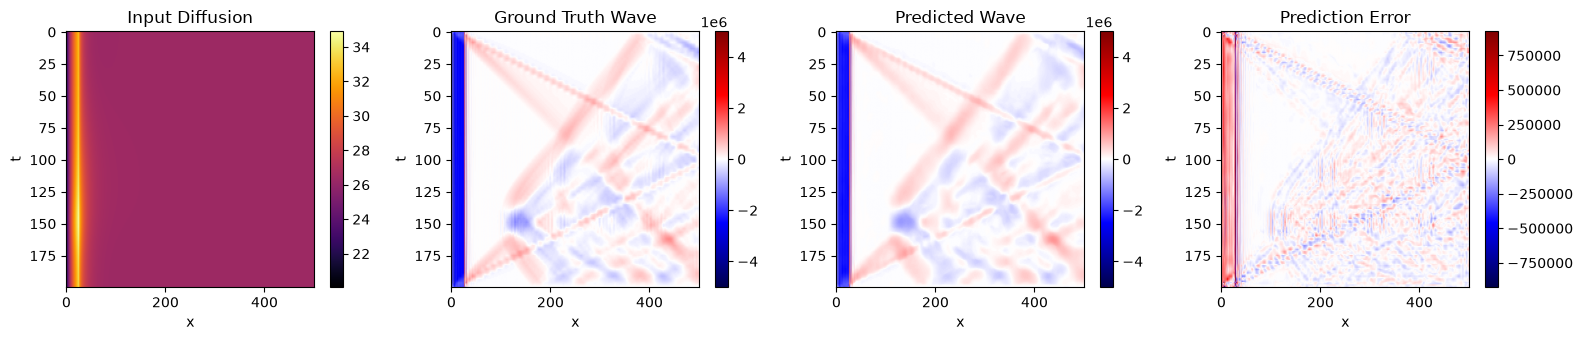

Figure saved to: latent_neural_operator_results/run_20260826_151559/visualization_prediction/prediction_comparison.png


In [12]:
import os
import glob
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# Visualization prediction
# ============================================================

PREDICT_FILE = os.path.join(
    DATA_ROOT,
    "1",
    "Irregular_3_PT_0.5.mat"
)

OUT_DIR_VIS = os.path.join(
    RUN_DIR,
    "visualization_prediction"
)

os.makedirs(
    OUT_DIR_VIS,
    exist_ok=True
)


# ============================================================
# Load prediction sample
# ============================================================

def load_prediction_sample(mat_path):

    assert os.path.isfile(mat_path), (
        f"Prediction file not found: {mat_path}"
    )

    with h5py.File(
        mat_path,
        "r"
    ) as f:

        PT = np.asarray(
            f["PT"],
            dtype=np.float32
        )

        if "PA" in f:

            PA = np.asarray(
                f["PA"],
                dtype=np.float32
            )

        else:

            PA = None


    if PT.shape == (
        200,
        501
    ):

        PT = PT.T


    if PA is not None:

        if PA.shape == (
            200,
            501
        ):

            PA = PA.T


    assert PT.shape == (
        NT,
        NX
    ), (
        f"Wrong PT shape: {PT.shape}"
    )


    if PA is not None:

        assert PA.shape == (
            NT,
            NX
        ), (
            f"Wrong PA shape: {PA.shape}"
        )


    return PT, PA


# ============================================================
# Load data
# ============================================================

PT_real, PA_real = load_prediction_sample(
    PREDICT_FILE
)


print(
    "PT shape:",
    PT_real.shape
)


if PA_real is not None:

    print(
        "PA ground-truth shape:",
        PA_real.shape
    )

else:

    print(
        "No PA ground truth found in this file."
    )


# ============================================================
# Normalize input
# ============================================================

PT_norm = (

    PT_real
    -
    pt_mean

) / pt_std


PT_tensor = torch.tensor(

    PT_norm,

    dtype=torch.float32

).unsqueeze(
    0

).unsqueeze(
    0

).to(
    DEVICE
)


print(
    "Network input shape:",
    PT_tensor.shape
)


# ============================================================
# Prediction
# ============================================================

model.eval()


with torch.no_grad():

    PA_pred_norm = model(
        PT_tensor
    )


PA_pred_norm = (

    PA_pred_norm
    .cpu()
    .squeeze(0)
    .squeeze(0)
    .numpy()
)


# ============================================================
# Denormalize predicted PA
# ============================================================

PA_pred = (

    PA_pred_norm
    *
    pa_std
    +
    pa_mean
)


print(
    "Predicted PA shape:",
    PA_pred.shape
)


# ============================================================
# Visualization
# ============================================================

if PA_real is not None:

    error = (
        PA_pred
        -
        PA_real
    )


    # --------------------------------------------------------
    # Transpose ONLY for visualization
    #
    # [501, 200] -> [200, 501]
    #
    # Same plotting direction as reference code
    # --------------------------------------------------------

    PT_plot = PT_real.T

    PA_real_plot = PA_real.T

    PA_pred_plot = PA_pred.T

    error_plot = error.T


    vmax = max(

        np.max(
            np.abs(
                PA_real_plot
            )
        ),

        np.max(
            np.abs(
                PA_pred_plot
            )
        )
    )


    evmax = np.max(
        np.abs(
            error_plot
        )
    )


    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 3.5)
    )


    # --------------------------------------------------------
    # Input PT
    # --------------------------------------------------------

    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    # --------------------------------------------------------
    # Ground truth PA
    # --------------------------------------------------------

    im1 = axes[1].imshow(

        PA_real_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Ground Truth Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    # --------------------------------------------------------
    # Predicted PA
    # --------------------------------------------------------

    im2 = axes[2].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[2].set_title(
        "Predicted Wave"
    )

    axes[2].set_xlabel(
        "x"
    )

    axes[2].set_ylabel(
        "t"
    )


    fig.colorbar(
        im2,
        ax=axes[2]
    )


    # --------------------------------------------------------
    # Error
    # --------------------------------------------------------

    im3 = axes[3].imshow(

        error_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-evmax,

        vmax=evmax
    )


    axes[3].set_title(
        "Prediction Error"
    )

    axes[3].set_xlabel(
        "x"
    )

    axes[3].set_ylabel(
        "t"
    )


    fig.colorbar(
        im3,
        ax=axes[3]
    )


    plt.tight_layout()


else:

    PT_plot = PT_real.T

    PA_pred_plot = PA_pred.T


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(9, 3.5)
    )


    im0 = axes[0].imshow(

        PT_plot,

        aspect="auto",

        cmap="inferno"
    )


    axes[0].set_title(
        "Input Diffusion"
    )

    axes[0].set_xlabel(
        "x"
    )

    axes[0].set_ylabel(
        "t"
    )


    fig.colorbar(
        im0,
        ax=axes[0]
    )


    vmax = np.max(
        np.abs(
            PA_pred_plot
        )
    )


    im1 = axes[1].imshow(

        PA_pred_plot,

        aspect="auto",

        cmap="seismic",

        vmin=-vmax,

        vmax=vmax
    )


    axes[1].set_title(
        "Predicted Wave"
    )

    axes[1].set_xlabel(
        "x"
    )

    axes[1].set_ylabel(
        "t"
    )


    fig.colorbar(
        im1,
        ax=axes[1]
    )


    plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plot_path = os.path.join(
    OUT_DIR_VIS,
    "prediction_comparison.png"
)


plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Figure saved to:",
    plot_path
)

